# CogniMap — Phase 2: Feature Engineering & EDA

Builds the (student, candidate_branch) modeling table from the 7 base CSVs,
then explores it. Each of the 2,000 students gets 7 rows — one per branch —
scored on the same 4 components used in `pathway_scoring.py`:

- **academic_fit** — avg marks in branch-relevant completed courses
- **skill_match_pct** — overlap between student skills and branch-career required skills
- **credit_completion_pct** — earned / required credits for that branch
- **prerequisite_satisfaction_pct** — completed prereqs / needed prereqs for remaining courses

`pathway_compatibility_score` = 0.35×academic_fit + 0.20×skill_match_pct + 0.25×credit_completion_pct + 0.20×prerequisite_satisfaction_pct

**Scope for this notebook:** feature engineering + EDA only — no model training yet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

DATA = "."
students = pd.read_csv(f"{DATA}/students.csv")
courses = pd.read_csv(f"{DATA}/courses.csv")
student_course = pd.read_csv(f"{DATA}/student_course.csv")
branches = pd.read_csv(f"{DATA}/branches.csv")
branch_reqs = pd.read_csv(f"{DATA}/branch_course_requirements.csv")
course_skill = pd.read_csv(f"{DATA}/course_skill.csv")
careers = pd.read_csv(f"{DATA}/careers.csv")

print(f"Students: {students.shape}, Courses: {courses.shape}, Student-Course: {student_course.shape}")


Students: (2000, 18), Courses: (59, 7), Student-Course: (27923, 7)


## 1. Feature Engineering

Precompute lookups once (dict-based) instead of re-filtering the DataFrames per row — 2,000 students × 7 branches = 14,000 rows, so this keeps it fast.

In [2]:
# --- Precompute per-branch requirement info ---
branch_required_ids = {}
branch_required_credits = {}
for b in branches.branch_id:
    ids = set(branch_reqs[(branch_reqs.branch_id == b) &
                           (branch_reqs.requirement_type.isin(["Foundational", "Core"]))]["course_id"])
    branch_required_ids[b] = ids
    branch_required_credits[b] = int(courses[courses.course_id.isin(ids)]["credits"].sum())

# --- Prerequisite map ---
prereq_map = courses.set_index("course_id")["prerequisite_course_id"].to_dict()

# --- Branch -> required skills (union across associated careers) ---
branch_required_skills = {}
for _, row in branches.iterrows():
    career_names = row["associated_careers"].split("|")
    skills = set()
    for cn in career_names:
        match = careers[careers.career_name == cn]
        if len(match):
            skills |= set(match.iloc[0]["required_skills"].split("|"))
    branch_required_skills[row["branch_id"]] = skills

# --- Per-student: completed course ids, credits earned per course, marks per course ---
completed = student_course[student_course.completion_status == "Completed"]
student_completed_ids = completed.groupby("student_id")["course_id"].apply(set).to_dict()
student_course_marks = completed.set_index(["student_id", "course_id"])["marks"].to_dict()

# --- Per-student: skill set (already stored on students.csv) ---
student_skills = students.set_index("student_id")["skills"].fillna("").apply(
    lambda s: set(s.split("|")) if s else set()
).to_dict()

student_avg_marks = students.set_index("student_id")["avg_marks"].to_dict()

print("Lookups built.")
print("Example — AIML required credits:", branch_required_credits["AIML"])
print("Example — AIML required skills:", branch_required_skills["AIML"])


Lookups built.
Example — AIML required credits: 65
Example — AIML required skills: {'Computer Vision', 'Machine Learning', 'Statistics', 'Embedded Systems', 'Python', 'Deep Learning', 'NLP', 'Data Analytics'}


In [3]:
def compute_row(student_id, branch, current_branch, current_semester):
    required_ids = branch_required_ids[branch]
    required_credits = branch_required_credits[branch]
    completed_ids = student_completed_ids.get(student_id, set())

    completed_relevant = completed_ids & required_ids
    earned_credits = int(courses[courses.course_id.isin(completed_relevant)]["credits"].sum()) if completed_relevant else 0
    credit_completion_pct = round(100 * earned_credits / required_credits, 1) if required_credits else 0.0

    remaining_ids = required_ids - completed_relevant
    needed_prereqs, satisfied = 0, 0
    for cid in remaining_ids:
        prereq = prereq_map.get(cid)
        if prereq is None or (isinstance(prereq, float) and pd.isna(prereq)):
            continue
        needed_prereqs += 1
        if prereq in completed_ids:
            satisfied += 1
    prereq_pct = round(100 * satisfied / needed_prereqs, 1) if needed_prereqs else 100.0

    req_skills = branch_required_skills[branch]
    s_skills = student_skills.get(student_id, set())
    skill_match_pct = round(100 * len(s_skills & req_skills) / len(req_skills), 1) if req_skills else 0.0

    relevant_marks = [student_course_marks[(student_id, cid)] for cid in completed_relevant
                       if (student_id, cid) in student_course_marks]
    academic_fit = round(np.mean(relevant_marks), 1) if relevant_marks else student_avg_marks.get(student_id, 0.0)

    composite = round(0.35 * academic_fit + 0.20 * skill_match_pct +
                       0.25 * credit_completion_pct + 0.20 * prereq_pct, 1)

    return dict(
        student_id=student_id, branch=branch, is_current_branch=(branch == current_branch),
        student_semester=current_semester,
        academic_fit=academic_fit, skill_match_pct=skill_match_pct,
        credit_completion_pct=credit_completion_pct, credits_earned=earned_credits,
        credits_required=required_credits, prerequisite_satisfaction_pct=prereq_pct,
        remaining_courses=len(remaining_ids), pathway_compatibility_score=composite,
    )

branch_ids = list(branches.branch_id)
rows = []
for _, s in students.iterrows():
    for b in branch_ids:
        rows.append(compute_row(s.student_id, b, s.current_branch, s.semester))

feature_table = pd.DataFrame(rows)
print(feature_table.shape)
feature_table.head(10)


(14000, 12)


,student_id,branch,is_current_branch,student_semester,academic_fit,skill_match_pct,credit_completion_pct,credits_earned,credits_required,prerequisite_satisfaction_pct,remaining_courses,pathway_compatibility_score
0,S00001,CSE,False,8,84.8,69.2,73.8,48,65,60.0,5,74.0
1,S00001,AIML,True,8,83.8,75.0,86.2,56,65,100.0,3,85.9
2,S00001,AIDS,False,8,84.9,77.8,76.5,52,68,60.0,5,76.4
3,S00001,IT,False,8,86.3,76.9,73.8,48,65,100.0,5,84.0
4,S00001,CYSEC,False,8,85.2,40.0,75.4,49,65,80.0,5,72.7
5,S00001,CSBS,False,8,85.3,80.0,71.6,48,67,83.3,6,80.4
6,S00001,IOT,False,8,85.7,83.3,73.8,48,65,60.0,5,77.1
7,S00002,CSE,True,3,91.7,23.1,29.2,19,65,33.3,13,50.7
8,S00002,AIML,False,3,91.7,12.5,29.2,19,65,41.7,13,50.2
9,S00002,AIDS,False,3,91.7,22.2,27.9,19,68,46.2,14,52.8


In [4]:
# Attach validation-only columns (NOT to be used as model features — see architecture doc Section 7)
val_cols = students.set_index("student_id")[["preferred_specialization", "career_interest", "cgpa"]]
feature_table = feature_table.merge(val_cols, on="student_id", how="left")

feature_table.to_csv("phase2_feature_table.csv", index=False)
print("Saved phase2_feature_table.csv:", feature_table.shape)
feature_table.sample(5, random_state=1)


Saved phase2_feature_table.csv: (14000, 15)


,student_id,branch,is_current_branch,student_semester,academic_fit,skill_match_pct,credit_completion_pct,credits_earned,credits_required,prerequisite_satisfaction_pct,remaining_courses,pathway_compatibility_score,preferred_specialization,career_interest,cgpa
12339,S01763,CSBS,False,6,85.5,60.0,77.6,52,67,100.0,5,81.3,IOT,Cloud Engineer,8.90
10123,S01447,AIML,False,8,82.6,50.0,81.5,53,65,75.0,4,74.3,AIML,Systems Administrator,8.48
13977,S01997,CSBS,False,3,71.6,20.0,29.9,20,67,53.8,14,47.3,IOT,Backend Developer,7.45
1520,S00218,AIML,False,3,74.6,12.5,35.4,23,65,58.3,12,49.1,IOT,IoT Solutions Engineer,8.04
5815,S00831,CSBS,True,7,75.7,100.0,92.5,62,67,100.0,2,89.6,CSBS,Business Systems Analyst,7.84


## 2. Exploratory Data Analysis

In [5]:
feature_table[["academic_fit", "skill_match_pct", "credit_completion_pct",
               "prerequisite_satisfaction_pct", "pathway_compatibility_score"]].describe().round(1)


,academic_fit,skill_match_pct,credit_completion_pct,prerequisite_satisfaction_pct,pathway_compatibility_score
count,14000.0,14000.0,14000.0,14000.0,14000.0
mean,76.8,38.1,60.8,62.5,62.2
std,11.3,22.7,18.3,17.8,10.8
min,43.5,0.0,14.7,0.0,24.8
25%,69.1,22.2,46.2,50.0,54.0
50%,77.3,37.5,69.2,61.5,61.7
75%,85.2,53.8,75.4,75.0,70.1
max,100.0,100.0,100.0,100.0,98.1


**Why this matters:** if `pathway_compatibility_score` were near-constant or bimodal at 0/100, that would signal leakage or lack of signal (the two failure modes found in the Kaggle datasets earlier in this project). A smooth, spread-out distribution is what we want to see here.

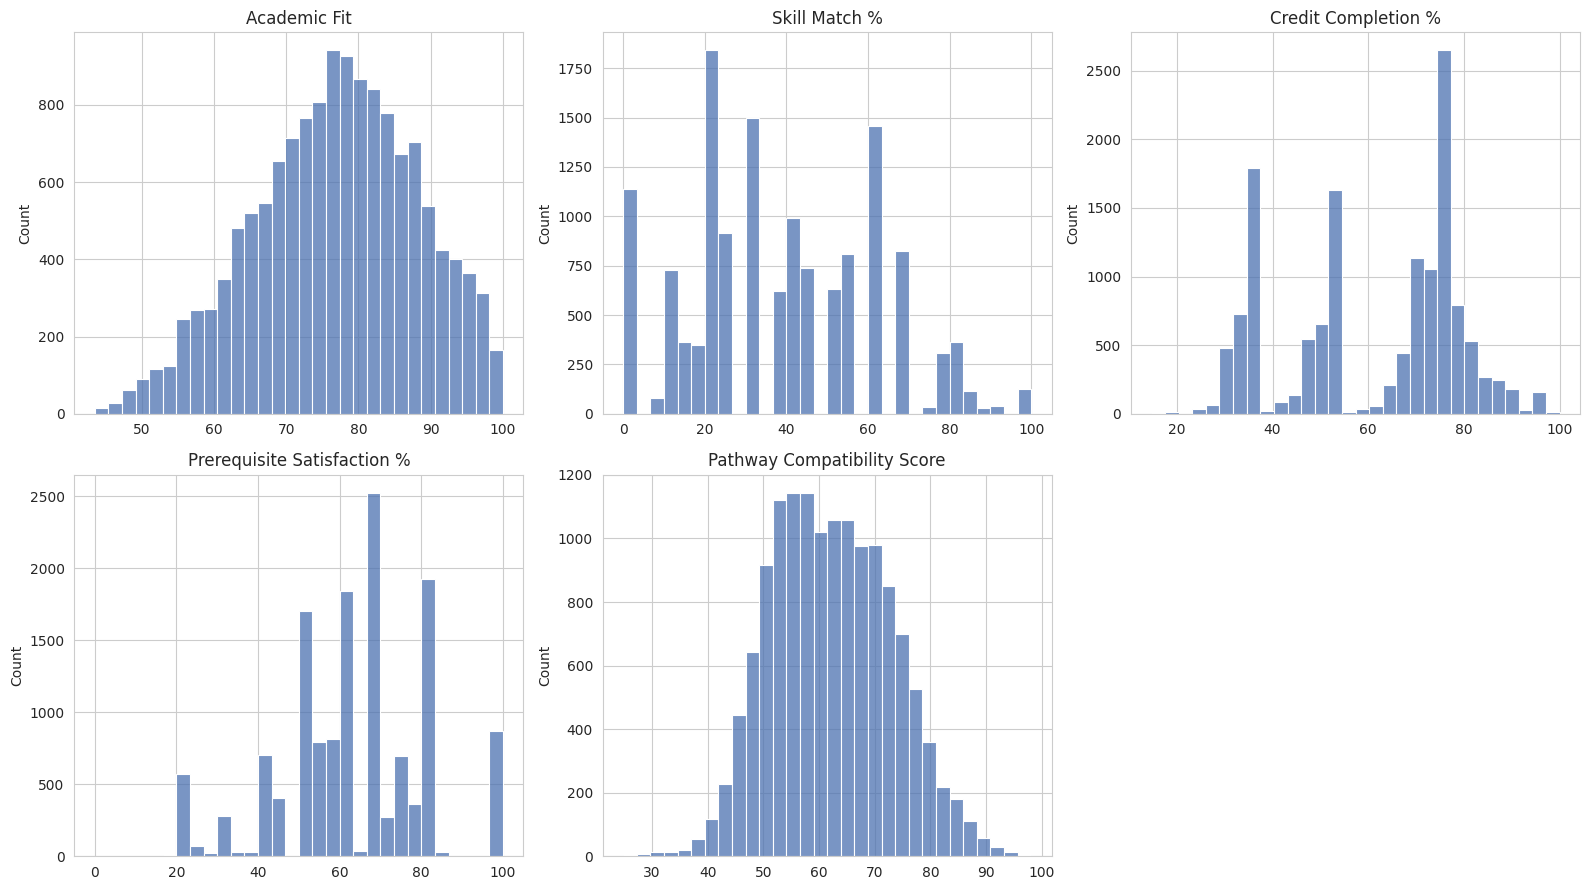

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols = ["academic_fit", "skill_match_pct", "credit_completion_pct",
        "prerequisite_satisfaction_pct", "pathway_compatibility_score"]
titles = ["Academic Fit", "Skill Match %", "Credit Completion %",
          "Prerequisite Satisfaction %", "Pathway Compatibility Score"]

for ax, col, title in zip(axes.flat, cols, titles):
    sns.histplot(feature_table[col], bins=30, ax=ax, color="#4C72B0")
    ax.set_title(title)
    ax.set_xlabel("")

axes.flat[5].axis("off")
plt.tight_layout()
plt.savefig("eda_component_distributions.png", dpi=120)
plt.show()


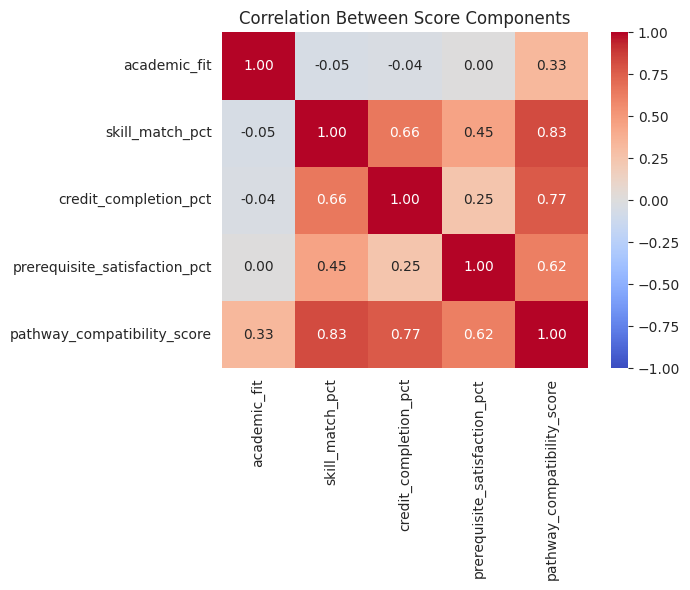

In [7]:
plt.figure(figsize=(7, 6))
corr = feature_table[["academic_fit", "skill_match_pct", "credit_completion_pct",
                       "prerequisite_satisfaction_pct", "pathway_compatibility_score"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Score Components")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=120)
plt.show()


### Does the score correctly favor a student's own branch?

Sanity check: the top-scoring branch per student should usually — but not always — be their `current_branch`. Always would suggest the score is just re-deriving the label (leakage); rarely would suggest the score is noise.

In [8]:
top_branch_per_student = (
    feature_table.sort_values("pathway_compatibility_score", ascending=False)
    .groupby("student_id")
    .first()[["branch", "is_current_branch", "pathway_compatibility_score"]]
)

match_rate = top_branch_per_student["is_current_branch"].mean()
print(f"Top-scoring branch == current branch for {match_rate:.1%} of students")

# Top-3 check
top3 = (feature_table.sort_values("pathway_compatibility_score", ascending=False)
        .groupby("student_id").head(3))
top3_match_rate = top3.groupby("student_id")["is_current_branch"].max().mean()
print(f"Current branch appears in top-3 recommendations for {top3_match_rate:.1%} of students")


Top-scoring branch == current branch for 28.3% of students
Current branch appears in top-3 recommendations for 56.8% of students


### Why isn't the match rate higher? — breaking down by semester

A flat 28% top-1 match rate needs explaining before it's trustworthy. The likely cause:
early-semester students have only completed **common-core courses**, which are required
equally by *all 7 branches* — so at that point in the program, branches genuinely
haven't differentiated yet for that student. This should resolve itself in later semesters
once branch-specific coursework accumulates.

In [9]:
top1_by_sem = top_branch_per_student.merge(
    students[["student_id", "semester"]], on="student_id"
).groupby("semester")["is_current_branch"].agg(["mean", "count"]).round(3)
top1_by_sem.columns = ["top1_match_rate", "n_students"]
print(top1_by_sem)

# Confirm the mechanism: credit completion, current vs other branch, by semester
check = feature_table.merge(students[["student_id", "semester"]], on="student_id")
credit_by_sem = check.groupby(["semester", "is_current_branch"])["credit_completion_pct"].mean().unstack().round(1)
credit_by_sem.columns = ["Other Branch", "Current Branch"]
print()
print("Avg credit_completion_pct — current vs. other branch, by semester:")
print(credit_by_sem)


          top1_match_rate  n_students
semester                             
3                   0.077         440
4                   0.074         433
5                   0.127         316
6                   0.338         272
7                   0.570         258
8                   0.786         281

Avg credit_completion_pct — current vs. other branch, by semester:
          Other Branch  Current Branch
semester                              
3                 33.9            34.0
4                 50.2            50.3
5                 71.6            71.8
6                 74.4            80.7
7                 75.7            88.4
8                 75.2            90.7


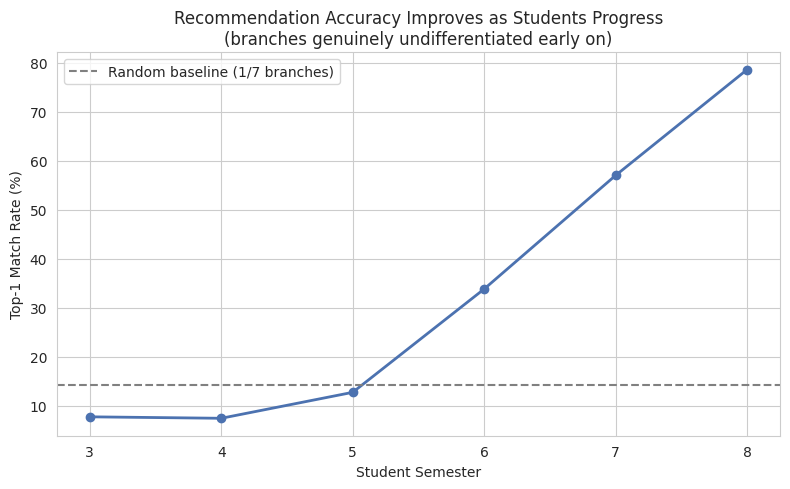

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(top1_by_sem.index, top1_by_sem.top1_match_rate * 100, marker="o", linewidth=2, color="#4C72B0")
plt.axhline(100/7, linestyle="--", color="gray", label="Random baseline (1/7 branches)")
plt.xlabel("Student Semester")
plt.ylabel("Top-1 Match Rate (%)")
plt.title("Recommendation Accuracy Improves as Students Progress\n(branches genuinely undifferentiated early on)")
plt.legend()
plt.tight_layout()
plt.savefig("eda_match_rate_by_semester.png", dpi=120)
plt.show()


**Interpretation:** this is a real, explainable pattern rather than a modeling flaw. By
semester 3-4, credit completion is statistically identical across branches (~34% for both
current and other branches) because only shared common-core courses have been taken. By
semester 8, current-branch credit completion (90.7%) is clearly ahead of other branches
(75.2%), and the top-1 match rate rises to ~79%. **This mirrors reality** — a 2nd-year
student genuinely hasn't committed to specialization-specific coursework yet, so a
recommendation system *should* be less confident about them than about a final-year
student. Consider reporting match rate **segmented by semester** rather than as a single
aggregate number in your results section — it's a more honest and more interesting story.

/tmp/ipykernel_565/2549701109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feature_table, x="is_current_branch", y="pathway_compatibility_score",


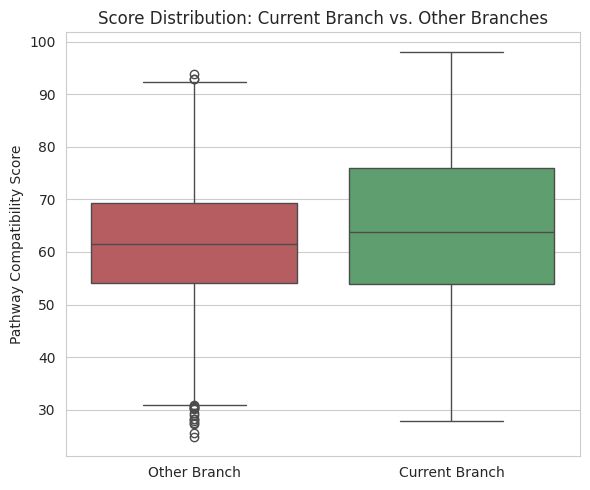

In [11]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=feature_table, x="is_current_branch", y="pathway_compatibility_score",
            palette=["#C44E52", "#55A868"])
plt.xticks([0, 1], ["Other Branch", "Current Branch"])
plt.xlabel("")
plt.ylabel("Pathway Compatibility Score")
plt.title("Score Distribution: Current Branch vs. Other Branches")
plt.tight_layout()
plt.savefig("eda_current_vs_other_branch.png", dpi=120)
plt.show()


### Cross-branch overlap: which non-current branches score highest?

This is the credit-aware angle — for students *not* currently in a branch, which branches still show meaningfully high scores (i.e., real secondary-pathway candidates)?

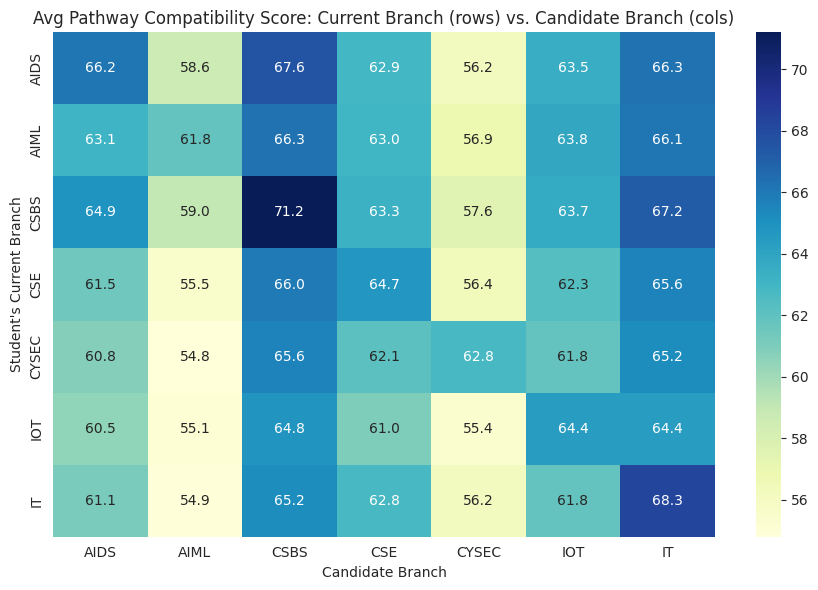

In [12]:
other_branch_rows = feature_table[~feature_table.is_current_branch]
avg_by_current_and_target = (
    feature_table.merge(students[["student_id", "current_branch"]], on="student_id", suffixes=("", "_dup"))
    .groupby(["current_branch", "branch"])["pathway_compatibility_score"]
    .mean().round(1).unstack()
)
plt.figure(figsize=(9, 6))
sns.heatmap(avg_by_current_and_target, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Avg Pathway Compatibility Score: Current Branch (rows) vs. Candidate Branch (cols)")
plt.ylabel("Student's Current Branch")
plt.xlabel("Candidate Branch")
plt.tight_layout()
plt.savefig("eda_cross_branch_heatmap.png", dpi=120)
plt.show()


## 3. Summary

- `phase2_feature_table.csv` (14,000 rows: 2,000 students × 7 branches) is the modeling table for Phase 5.
- The diagonal of the cross-branch heatmap (current branch vs. itself) should be visibly higher than off-diagonal cells, confirming real signal — but off-diagonal cells for domain-adjacent branches (e.g. AIDS→AIML, CSBS→AIDS) should still be noticeably elevated above unrelated pairs, confirming genuine credit/skill overlap rather than a flat baseline.
- **Reminder:** `preferred_specialization` and `career_interest` are attached here for validation only — do not use them as model input features (see architecture doc, Section 7).

**Next step (Phase 5):** train a regression model (e.g. Random Forest Regressor) on `phase2_feature_table.csv` using the four component columns as features and `pathway_compatibility_score` as target, then evaluate top-3 ranking accuracy against `preferred_specialization` as a held-out qualitative check.